In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

gxl     = pd.read_csv("../data/gxl_ratios.csv")
fin_df  = pd.read_csv("../data/financials.csv")

print("Datos cargados OK")
print(fin_df[["company", "ev_revenue", "ev_ebitda", "gross_margins"]].to_string(index=False))

Datos cargados OK
      company  ev_revenue  ev_ebitda  gross_margins
 Gerresheimer       1.346      8.721        0.23624
Schott Pharma       2.928     11.329        0.32936
    Stevanato       4.592     19.147        0.29219
   AptarGroup       2.416     11.599        0.36672


In [2]:
comp = fin_df.copy()
comp["gross_margins"] = (comp["gross_margins"] * 100).round(1)
comp["revenue_growth"] = (comp["revenue_growth"] * 100).round(1)
comp["ev_revenue"] = comp["ev_revenue"].round(2)
comp["ev_ebitda"]  = comp["ev_ebitda"].round(2)
comp["pe_ratio"]   = comp["pe_ratio"].round(1)

# Peer median (excluir Gerresheimer)
peers = comp[comp["company"] != "Gerresheimer"]
peer_median_ev_rev  = peers["ev_revenue"].median()
peer_median_ev_ebit = peers["ev_ebitda"].median()

median_row = pd.DataFrame([{
    "company":       "Peer Median",
    "ev_revenue":    round(peer_median_ev_rev, 2),
    "ev_ebitda":     round(peer_median_ev_ebit, 2),
    "pe_ratio":      round(peers["pe_ratio"].median(), 1),
    "gross_margins": round(peers["gross_margins"].median(), 1),
    "revenue_growth":round(peers["revenue_growth"].median(), 1),
}])

comp_table = pd.concat([comp, median_row], ignore_index=True)

print("Comparable Company Analysis:")
print(comp_table[["company", "ev_revenue", "ev_ebitda",
                  "pe_ratio", "gross_margins"]].to_string(index=False))
print(f"\nPeer Median EV/Revenue: {peer_median_ev_rev:.2f}x")
print(f"Peer Median EV/EBITDA:  {peer_median_ev_ebit:.2f}x")

Comparable Company Analysis:
      company  ev_revenue  ev_ebitda  pe_ratio  gross_margins
 Gerresheimer        1.35       8.72      41.4           23.6
Schott Pharma        2.93      11.33      18.4           32.9
    Stevanato        4.59      19.15      32.8           29.2
   AptarGroup        2.42      11.60      21.7           36.7
  Peer Median        2.93      11.60      21.7           32.9

Peer Median EV/Revenue: 2.93x
Peer Median EV/EBITDA:  11.60x


In [3]:
gxl_current = fin_df[fin_df["company"] == "Gerresheimer"].iloc[0]

ev_actual        = gxl_current["enterprise_value"]
revenue_ttm      = gxl_current["revenue_ttm"]
ebitda_ttm       = gxl_current["ebitda"]

implied_ev_rev   = peer_median_ev_rev  * revenue_ttm
implied_ev_ebit  = peer_median_ev_ebit * ebitda_ttm

upside_rev  = ((implied_ev_rev  - ev_actual) / ev_actual * 100).round(1)
upside_ebit = ((implied_ev_ebit - ev_actual) / ev_actual * 100).round(1)

print("Implied Valuation vs Current:")
print(f"  Current EV:                   EUR {ev_actual/1e9:.2f}bn")
print(f"  Implied EV (EV/Revenue):      EUR {implied_ev_rev/1e9:.2f}bn  → {upside_rev:+.1f}%")
print(f"  Implied EV (EV/EBITDA):       EUR {implied_ev_ebit/1e9:.2f}bn  → {upside_ebit:+.1f}%")
print(f"\n  Current EV/Revenue:  {gxl_current['ev_revenue']:.2f}x  vs Peer Median: {peer_median_ev_rev:.2f}x")
print(f"  Current EV/EBITDA:   {gxl_current['ev_ebitda']:.2f}x  vs Peer Median: {peer_median_ev_ebit:.2f}x")

Implied Valuation vs Current:
  Current EV:                   EUR 3.12bn
  Implied EV (EV/Revenue):      EUR 6.80bn  → +117.7%
  Implied EV (EV/EBITDA):       EUR 4.16bn  → +33.0%

  Current EV/Revenue:  1.35x  vs Peer Median: 2.93x
  Current EV/EBITDA:   8.72x  vs Peer Median: 11.60x


In [4]:
# Supuestos DCF
latest_ebitda  = gxl.iloc[-1]["ebitda_adj"]    # EUR mn
latest_capex   = gxl.iloc[-1]["capex"]          # EUR mn
latest_revenue = gxl.iloc[-1]["revenue"]        # EUR mn
net_debt       = gxl.iloc[-1]["net_debt"]        # EUR mn
shares_out     = 33.3                            # millones (Annual Report 2023)

WACC           = 0.085   # 8.5% — típico pharma packaging
terminal_growth= 0.025   # 2.5% — en línea con PIB europeo

# Proyecciones 5 años (escenarios)
scenarios = {
    "Bull":  {"revenue_cagr": 0.10, "ebitda_margin_target": 0.28},
    "Base":  {"revenue_cagr": 0.07, "ebitda_margin_target": 0.26},
    "Bear":  {"revenue_cagr": 0.04, "ebitda_margin_target": 0.24},
}

dcf_results = {}

for scenario, params in scenarios.items():
    rev = latest_revenue
    fcfs = []

    for year in range(1, 6):
        rev         = rev * (1 + params["revenue_cagr"])
        ebitda      = rev * params["ebitda_margin_target"]
        capex_est   = rev * 0.13          # capex intensity normalizada
        tax_rate    = 0.28
        ebit        = ebitda * 0.65       # D&A ~35% of EBITDA
        nopat       = ebit * (1 - tax_rate)
        da          = ebitda - ebit
        fcf         = nopat + da - capex_est
        fcfs.append(fcf)

    # Terminal value
    terminal_fcf = fcfs[-1] * (1 + terminal_growth)
    terminal_val = terminal_fcf / (WACC - terminal_growth)

    # DCF
    pv_fcfs = sum([fcf / (1 + WACC)**i for i, fcf in enumerate(fcfs, 1)])
    pv_term = terminal_val / (1 + WACC)**5

    enterprise_val = pv_fcfs + pv_term
    equity_val     = enterprise_val - net_debt
    price_per_share= equity_val / shares_out

    dcf_results[scenario] = {
        "enterprise_value": round(enterprise_val, 0),
        "equity_value":     round(equity_val, 0),
        "price_per_share":  round(price_per_share, 1),
        "pv_fcfs":          round(pv_fcfs, 0),
        "pv_terminal":      round(pv_term, 0),
    }

print("DCF Valuation Results:")
print(f"{'Scenario':<10} {'EV (EUR mn)':<15} {'Equity (EUR mn)':<18} {'Price/Share'}")
print("-" * 55)
for s, r in dcf_results.items():
    print(f"{s:<10} {r['enterprise_value']:<15,.0f} {r['equity_value']:<18,.0f} EUR {r['price_per_share']:.1f}")

DCF Valuation Results:
Scenario   EV (EUR mn)     Equity (EUR mn)    Price/Share
-------------------------------------------------------
Bull       4,584           3,164              EUR 95.0
Base       3,375           1,955              EUR 58.7
Bear       2,381           961                EUR 28.9


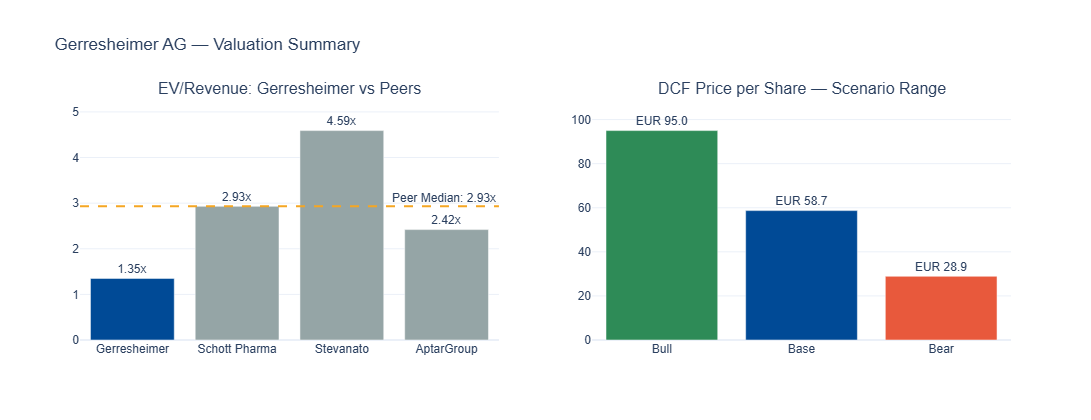

In [5]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=(
        "EV/Revenue: Gerresheimer vs Peers",
        "DCF Price per Share — Scenario Range"
    ))

# EV/Revenue comps
comp_plot = comp_table[comp_table["company"] != "Peer Median"]
bar_colors = ["#004A96" if c == "Gerresheimer" else "#95A5A6"
              for c in comp_plot["company"]]

fig.add_trace(go.Bar(
    x=comp_plot["company"],
    y=comp_plot["ev_revenue"],
    marker_color=bar_colors,
    showlegend=False,
    text=comp_plot["ev_revenue"].astype(str) + "x",
    textposition="outside"
), row=1, col=1)

fig.add_hline(
    y=peer_median_ev_rev,
    line_dash="dash", line_color="#F5A623",
    annotation_text=f"Peer Median: {peer_median_ev_rev:.2f}x",
    row=1, col=1
)

# DCF scenarios
scenarios_list = list(dcf_results.keys())
prices_dcf     = [dcf_results[s]["price_per_share"] for s in scenarios_list]
bar_colors_dcf = ["#2E8B57", "#004A96", "#E8593C"]

fig.add_trace(go.Bar(
    x=scenarios_list,
    y=prices_dcf,
    marker_color=bar_colors_dcf,
    showlegend=False,
    text=[f"EUR {p:.1f}" for p in prices_dcf],
    textposition="outside"
), row=1, col=2)

fig.update_layout(
    title="Gerresheimer AG — Valuation Summary",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=420
)

fig.show()

In [6]:
comp_table.to_csv("../data/comparable_analysis.csv", index=False)

dcf_df = pd.DataFrame(dcf_results).T.reset_index()
dcf_df.columns = ["scenario"] + list(dcf_df.columns[1:])
dcf_df.to_csv("../data/dcf_results.csv", index=False)

print("Guardado OK")
print(dcf_df.to_string(index=False))

Guardado OK
scenario  enterprise_value  equity_value  price_per_share  pv_fcfs  pv_terminal
    Bull            4584.0        3164.0             95.0   1016.0       3568.0
    Base            3375.0        1955.0             58.7    781.0       2594.0
    Bear            2381.0         961.0             28.9    576.0       1805.0
